### Random Forest model:
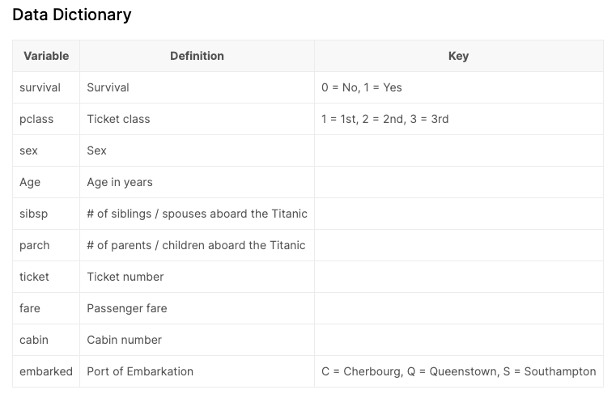

In [1]:
# importing libraries
import pandas as pd, numpy as np
import matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [2]:
# reading the csv file
train_data = pd.read_csv("train.csv")
test_data = pd.read_csv("test.csv")

In [3]:
# removing the unwanted columns from training dataset with drop function
train_data = train_data.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked'], axis=1)
test_data = test_data.drop(['PassengerId', 'Name', 'SibSp', 'Parch', 'Ticket', 'Cabin', 'Embarked'], axis=1)

In [4]:
# exploring the categorical columns
x_train = train_data.drop('Survived', axis=1)
x_train.replace({'male':0, 'female':1}, inplace=True)
test_data.replace({'male':0, 'female':1},inplace=True)
y_train = train_data['Survived']
x_test = test_data.values
x_test

array([[ 3.    ,  0.    , 34.5   ,  7.8292],
       [ 3.    ,  1.    , 47.    ,  7.    ],
       [ 2.    ,  0.    , 62.    ,  9.6875],
       ...,
       [ 3.    ,  0.    , 38.5   ,  7.25  ],
       [ 3.    ,  0.    ,     nan,  8.05  ],
       [ 3.    ,  0.    ,     nan, 22.3583]])

In [5]:
# checking for null values
x_train.isnull().sum()

Pclass      0
Sex         0
Age       177
Fare        0
dtype: int64

In [6]:
# filling the missing values with mean of all values in column Age
x_train.Age = x_train.Age.fillna(x_train.Age.mean())
test_data.Age = test_data.Age.fillna(test_data.Age.mean())
test_data.Fare = test_data.Fare.fillna(test_data.Fare.mean())

In [7]:
# training the data with Random Forest model
from sklearn.ensemble import RandomForestClassifier
random_forest = RandomForestClassifier(random_state=42, n_jobs=-1, max_depth=5,
                                       n_estimators=100, oob_score=True)
random_forest.fit(x_train, y_train)

RandomForestClassifier(max_depth=5, n_jobs=-1, oob_score=True, random_state=42)

In [8]:
# oob score: computed as the number of correctly predicted rows from the out of bag sample.
# It is a random forest cross-validation method. These samples are the ones not used to train the data
# instead used to evaluate its performance. These samples are called out of bag samples.
# Out-Of-Bag score. It’s a way to evaluate the model’s performance without using a separate validation set.
random_forest.oob_score_

0.8271604938271605

In Random Forest, each tree is trained on a bootstrap sample, which is a random sample with replacement from the original dataset. On average, about 63% of the data is used for training each tree, while the remaining 37% (the OOB samples) are left out.

The OOB score is the accuracy or R² score (depending on whether it’s a classifier or regressor) of the model on these left-out samples.

It acts like a built-in cross-validation, saving you the need for a separate validation set.

It provides an unbiased performance estimate of the model.

It helps prevent overfitting by testing on unseen data.

- When to use 4-fold CV?

Fewer folds → Larger test sets (25% of the data for testing in each fold).

Faster training because the model is trained only 4 times.

Less reliable performance estimate if the dataset is small, as each fold contains fewer training samples.

Higher bias, lower variance → The results are more stable but less flexible.

Use 4-fold when:

You have large datasets where you don't need too many folds.

You prioritize faster training over minor improvements in performance estimates.

- 2. When to use 10-fold CV

More folds → Smaller test sets (10% of the data for testing in each fold).

More reliable performance estimate because more data is used for training in each fold.

Higher variance, lower bias → The model captures more complexity but may be less stable.

More computationally expensive due to 10 training runs.

Use 10-fold when:

Your dataset is small and you want a better performance estimate.

You want a more accurate measure of the model’s generalization ability.

You’re fine with the extra computational cost.

In [9]:
# hyperparameter tuning for Random Forest using GridSearchCV and fitting the data.
# n_estimators int, default=100: The number of trees in the forest.
from sklearn.model_selection import GridSearchCV
rf = RandomForestClassifier(random_state=42, n_jobs=-1)
params = {
    'max_depth': [2,3,5,10,20],
    'min_samples_leaf': [5,10,20,50,100,200],
    'n_estimators': [10,25,30,50,100,200]
}
grid_search = GridSearchCV(estimator=rf,
                           param_grid=params,
                           cv = 4,
                           n_jobs=-1, verbose=1, scoring="accuracy")
grid_search.fit(x_train, y_train)

Fitting 4 folds for each of 180 candidates, totalling 720 fits


GridSearchCV(cv=4, estimator=RandomForestClassifier(n_jobs=-1, random_state=42),
             n_jobs=-1,
             param_grid={'max_depth': [2, 3, 5, 10, 20],
                         'min_samples_leaf': [5, 10, 20, 50, 100, 200],
                         'n_estimators': [10, 25, 30, 50, 100, 200]},
             scoring='accuracy', verbose=1)

The parameters max_depth, min_samples_leaf, and n_estimators in RandomForestClassifier control the complexity, regularization, and ensemble size of the model. Tuning these parameters can significantly impact the model's accuracy and generalization.

- n_estimators: Number of trees in the forest

The number of decision trees in the ensemble.

More trees → Better stability and accuracy but slower training.

Increasing n_estimators improves performance but with diminishing returns.

Typical values:

100 (default): Balanced performance and speed.

200–500: Often used for more robust models.

Higher values are only useful for large datasets or very complex problems.

Tip:

Start with 100 or 200 and increase it if necessary.

Beyond a certain point (e.g., 500+), adding more trees may not significantly improve accuracy.


- Tuning Tips:

Use GridSearchCV or RandomizedSearchCV to find the best combination of these parameters.

For large datasets, focus on min_samples_leaf and max_depth to prevent overfitting.

For smaller datasets, increase n_estimators to stabilize the model.

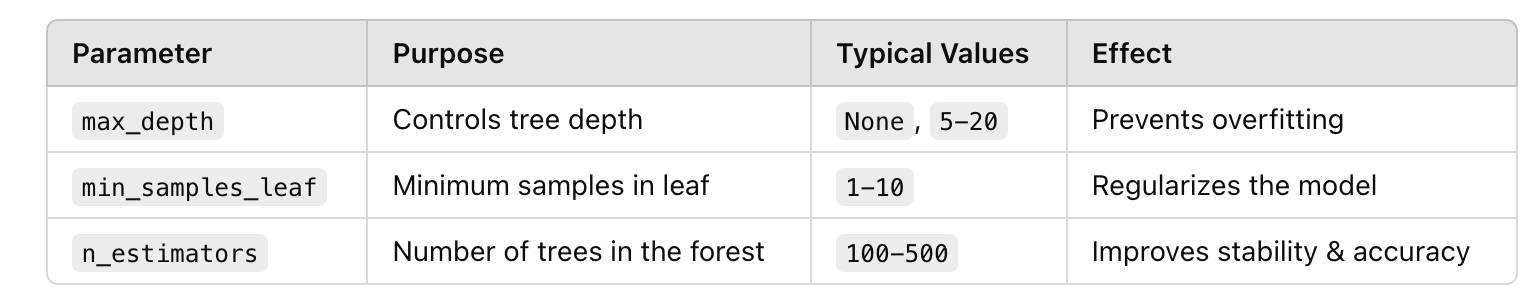

In [10]:
grid_search.best_score_

0.8226831091180867

Cell number 11
We can see the best values for the parameters that are found by GridSearchCV.

Cell number 12
You can double-click on this plot to zoom in to see each subtree and the estimation for each person as Survived and Not Survived.

In [11]:
rf_best = grid_search.best_estimator_
rf_best

RandomForestClassifier(max_depth=20, min_samples_leaf=5, n_estimators=30,
                       n_jobs=-1, random_state=42)

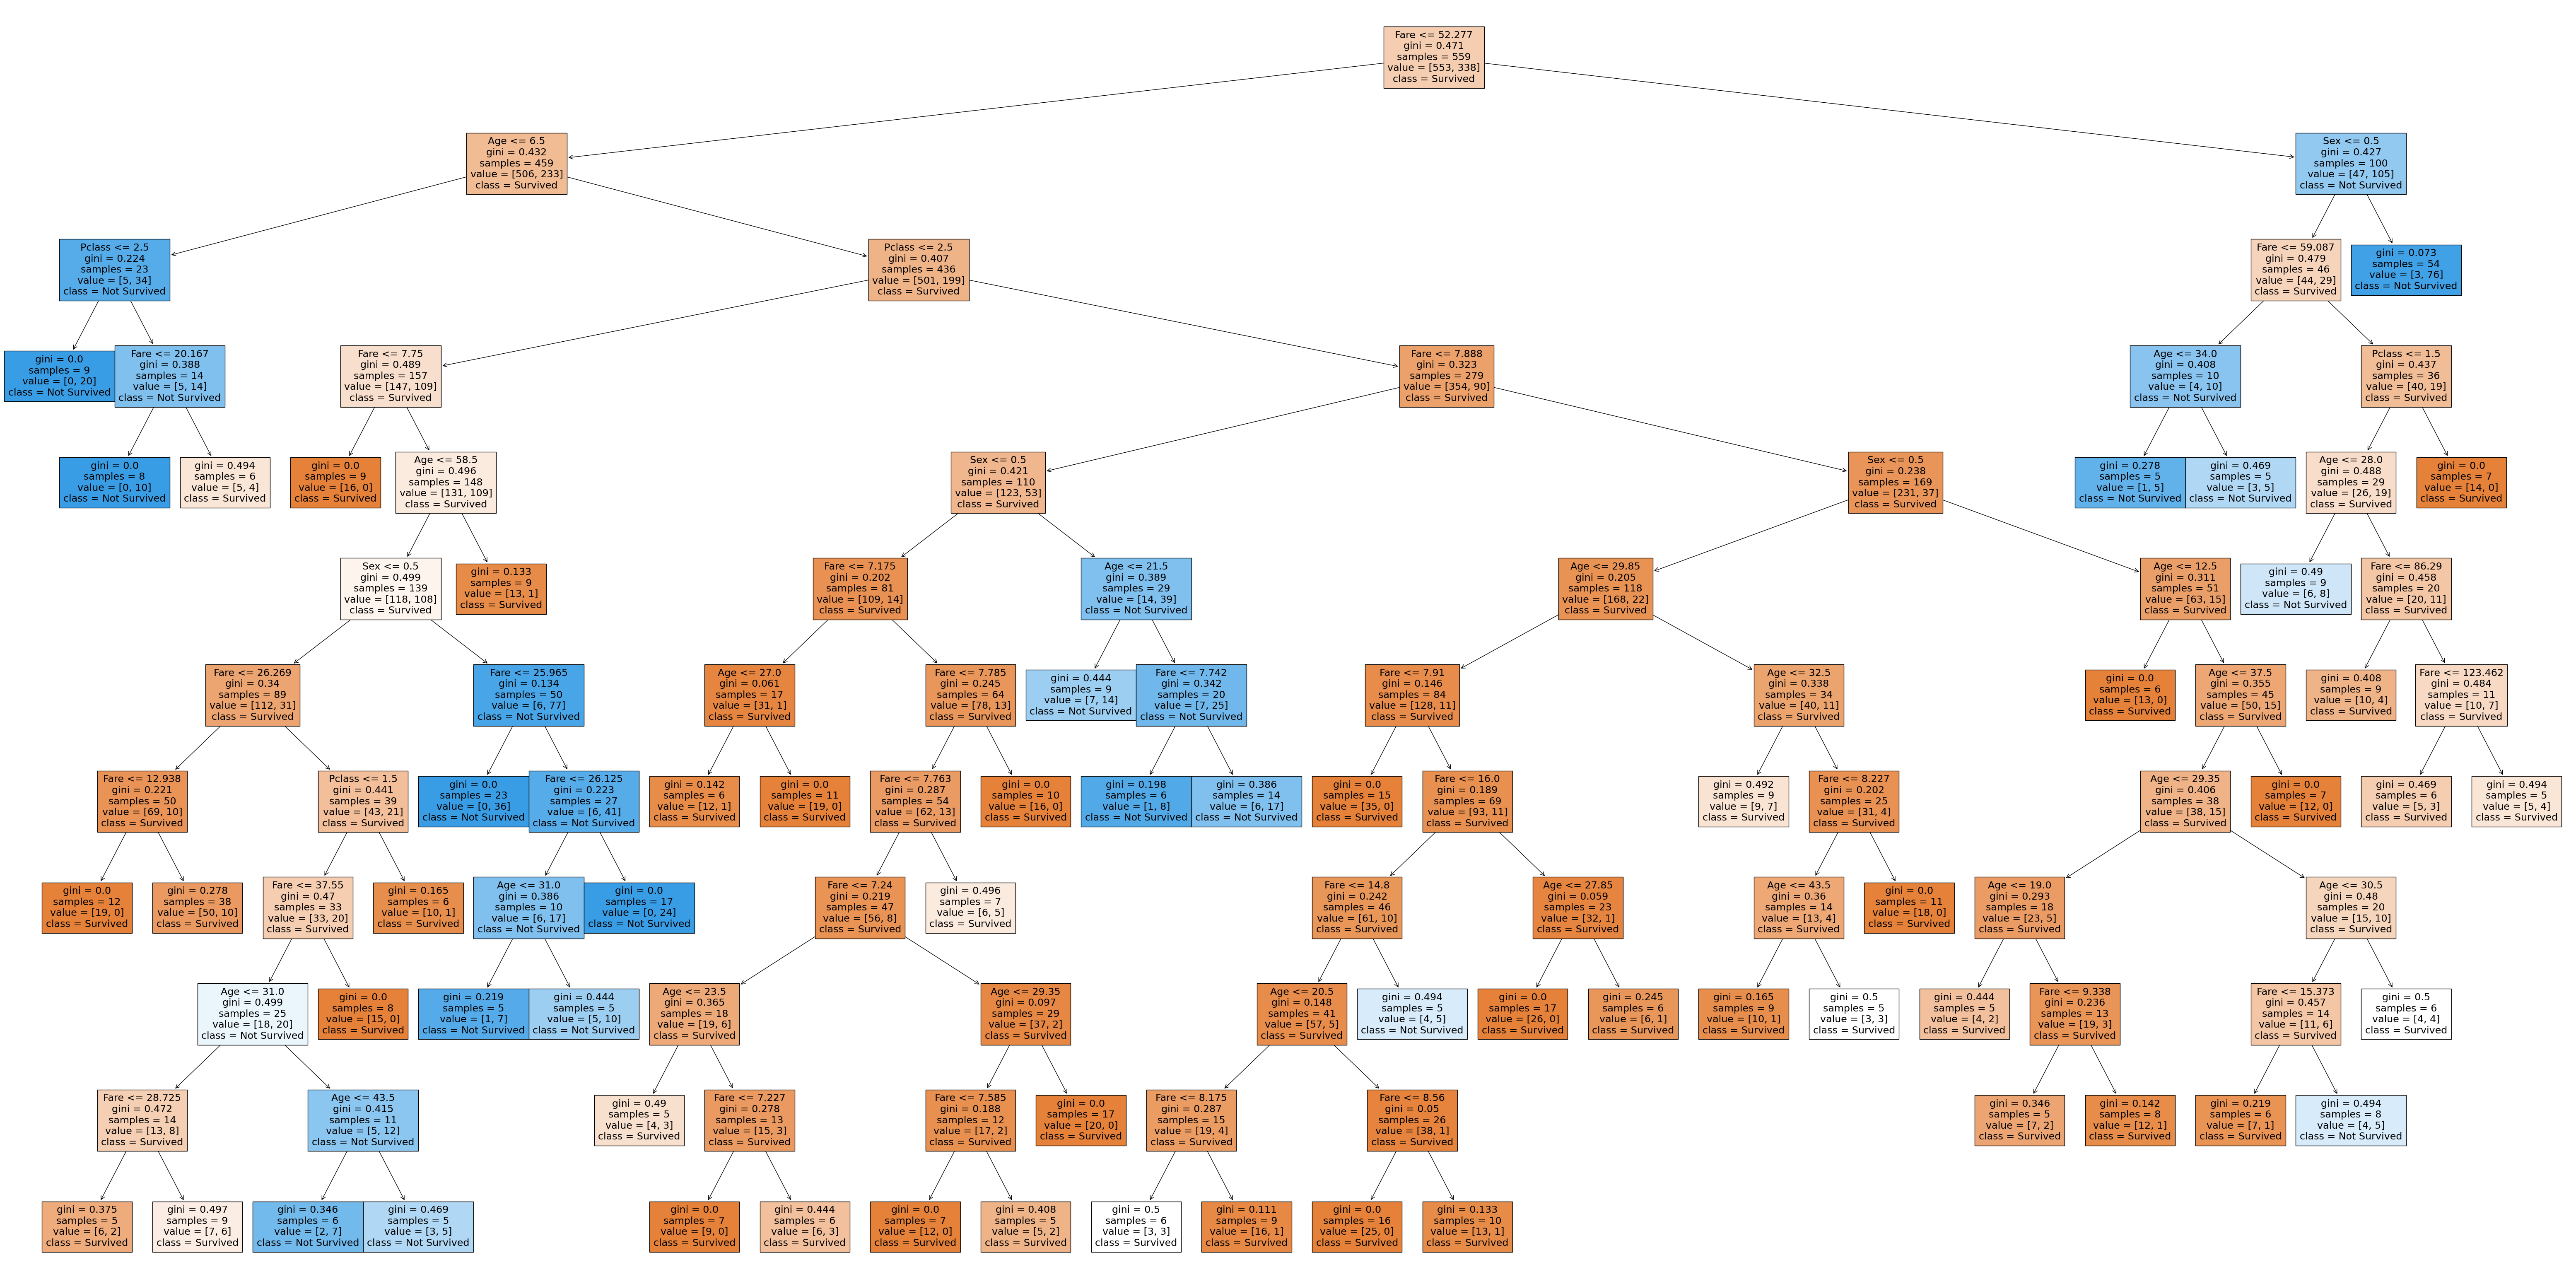

In [12]:
from sklearn.tree import plot_tree
plt.figure(figsize=(80,40))
plot_tree(rf_best.estimators_[5], feature_names = x_train.columns,class_names=['Survived', "Not Survived"],
          filled=True);

It shows the importance score of each feature in predicting the target variable. It indicates how much a particular feature contributes to reducing impurity (Gini or entropy) across all the trees in the forest.

- How is it calculated?

For each feature:

The model measures how much the Gini impurity (or entropy) decreases when splitting on that feature.

The impurity reduction is averaged across all trees.

The final importance score is normalized to sum up to 1.

- Interpreting the Scores:

Higher values → More important features

Lower values → Less important features

In [13]:
rf_best.feature_importances_

array([0.13224931, 0.44628182, 0.18147381, 0.23999506])

In [14]:
imp_df = pd.DataFrame({
    "Varname": x_train.columns,
    "Imp": rf_best.feature_importances_
})
imp_df.sort_values(by="Imp", ascending=False)

,Varname,Imp
1,Sex,0.446282
3,Fare,0.239995
2,Age,0.181474
0,Pclass,0.132249
